<a href="https://colab.research.google.com/github/LemonMeringue01/EDAwk1/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title Section. Week 2 EDA.


# Section - Mostly as-in tutorial

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,RobustScaler
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv('weather_data_extended.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Location          800 non-null    object 
 1   Temperature (°C)  800 non-null    float64
 2   Feels Like (°C)   800 non-null    float64
 3   Humidity (%)      798 non-null    float64
 4   Wind Speed (kph)  798 non-null    float64
 5   Cloud Cover (%)   800 non-null    int64  
 6   Pressure (mb)     798 non-null    float64
 7   UV Index          800 non-null    int64  
 8   Visibility (km)   800 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 56.4+ KB


,Location,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
0,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
1,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
2,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
3,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
4,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16


In [6]:
df.isnull().sum()

,0
Location,0
Temperature (°C),0
Feels Like (°C),0
Humidity (%),2
Wind Speed (kph),2
Cloud Cover (%),0
Pressure (mb),2
UV Index,0
Visibility (km),0


In [7]:
#dropping missing values
df=df.dropna()
df.isnull().sum()

,0
Location,0
Temperature (°C),0
Feels Like (°C),0
Humidity (%),0
Wind Speed (kph),0
Cloud Cover (%),0
Pressure (mb),0
UV Index,0
Visibility (km),0


In [8]:
df.describe()

,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
count,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000
mean,16.580730,16.373804,73.513854,16.123300,43.513854,1013.041562,1.746851,10.732997
std,5.574821,7.382814,16.478897,10.338986,34.845115,7.608453,1.092285,1.966105
min,8.300000,4.500000,40.000000,3.600000,0.000000,900.000000,1.000000,10.000000
25%,15.000000,13.800000,67.000000,6.100000,0.000000,1012.000000,1.000000,10.000000
50%,16.000000,16.000000,76.000000,9.000000,50.000000,1013.000000,1.000000,10.000000
75%,24.000000,25.500000,88.000000,24.100000,75.000000,1019.250000,2.000000,10.000000
max,25.000000,27.800000,100.000000,29.900000,75.000000,1024.000000,4.000000,16.000000


In [9]:
# String indexing on 'Location' column: Converting Location column from string to integer
df['Location_index'] = df['Location'].astype('category').cat.codes

# Get unique values from each column
unique_locations = df['Location'].drop_duplicates().reset_index(drop=True)
unique_location_indices = df['Location_index'].drop_duplicates().reset_index(drop=True)

# Create a new DataFrame with both columns
unique_df = pd.DataFrame({
    'Unique_Locations': unique_locations,
    'Unique_Location_Indices': unique_location_indices
})
unique_df

,Unique_Locations,Unique_Location_Indices
0,New York,3
1,London,2
2,Tokyo,7
3,Paris,4
4,Sydney,6
5,Dubai,0
6,Rome,5
7,Hong Kong,1


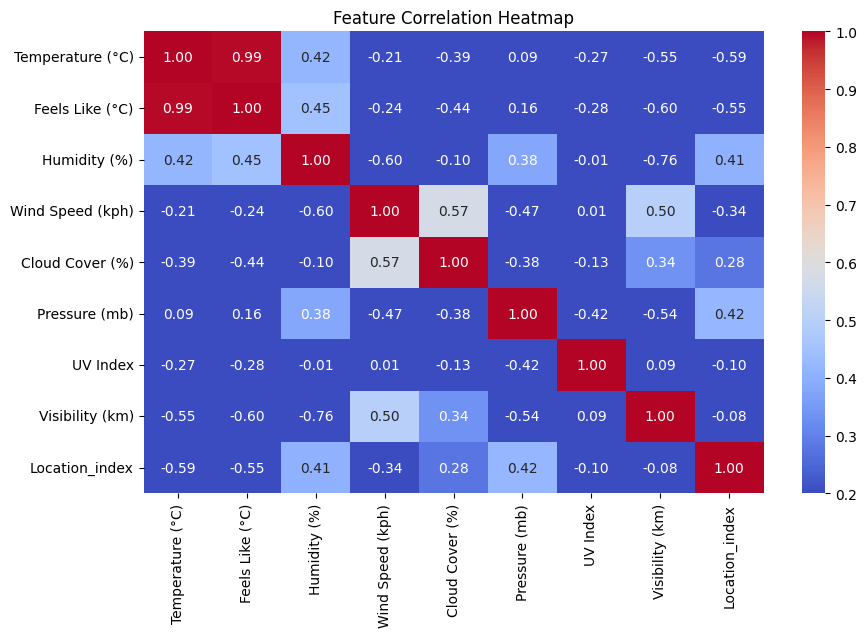

rudimentary method. from altered diagram, somewhat more related items are: 
 [Temp and feels like], 
 [temp, feels like and Humidity], 
 [cloud cover and wind speed], 
 [pressure and humidity], 
 [visibility and wind speed], 
 [visibility and cloud cover], 
 [location index and humidity], 
 [cloud cover and location], 
 [pressure and location index]


In [15]:
# Select only numeric columns before correlation
numeric_df = df.select_dtypes(include=['number'])

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=0.2, vmax=1.0)#values vmin and vmax change the scale.
plt.title('Feature Correlation Heatmap')
plt.show()

print("rudimentary method. from altered diagram, somewhat more related items are: \n [Temp and feels like], \n [temp, feels like and Humidity], \n [cloud cover and wind speed], \n [pressure and humidity], \n [visibility and wind speed], \n [visibility and cloud cover], \n [location index and humidity], \n [cloud cover and location], \n [pressure and location index]")


Location and location_index make for poor boxplots. 
 temperature is mainly within 15 and 23 degrees celsius though ranges a lot lower, 
 feels like is very similar to temp, ranging above the max and min temps 
 Humidity varies, never below 40%, bulk at 68 to 88% 
 wind speed ranges from 3 to 30kph, most below 24kph, 
 cloud cover ranges from 0 to near 80, 
 pressure has a severe low outlier that should be removed, 
 as with UV index and visibility - esp visibility.


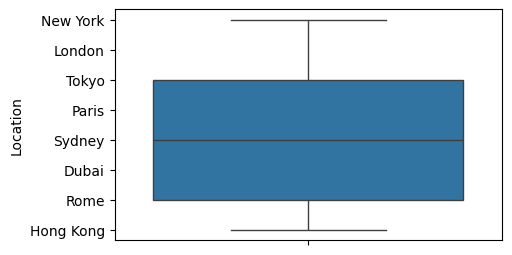

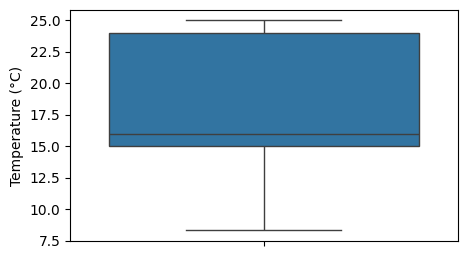

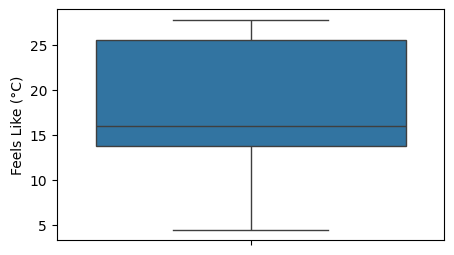

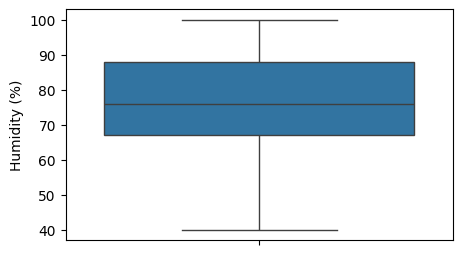

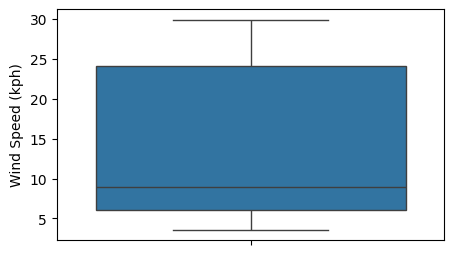

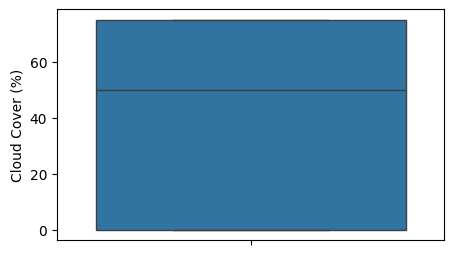

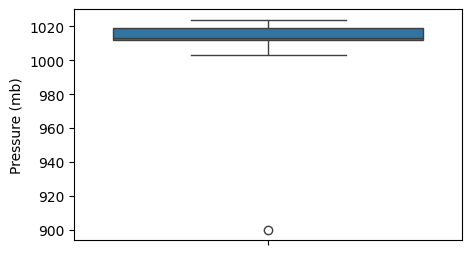

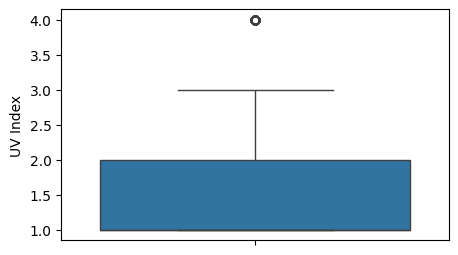

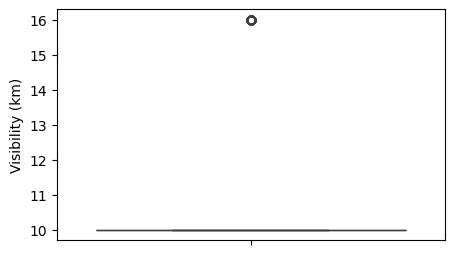

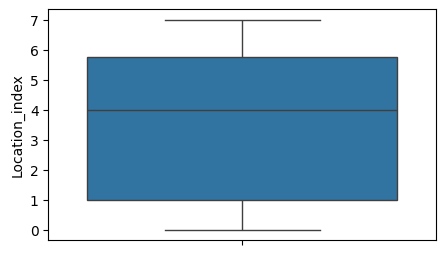

In [47]:

for attr in df:
  plt.figure(figsize=(5,3))
  sns.boxplot(data=df[attr])
  plt.show

print("Location and location_index make for poor boxplots. \n temperature is mainly within 15 and 23 degrees celsius though ranges a lot lower, \n feels like is very similar to temp, ranging above the max and min temps \n Humidity varies, never below 40%, bulk at 68 to 88% \n wind speed ranges from 3 to 30kph, most below 24kph, \n cloud cover ranges from 0 to near 80, \n pressure has a severe low outlier that should be removed, \n as with UV index and visibility - esp visibility.")

In [48]:
X = df[['Humidity (%)', 'Wind Speed (kph)', 'Pressure (mb)', 'Visibility (km)', 'Location_index']] #features
y = df['Temperature (°C)'] #target variable or label

In [49]:
# Standard scaling the values in features
scaler = RobustScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print(df_scaled.describe())

       Humidity (%)  Wind Speed (kph)  Pressure (mb)  Visibility (km)  \
count    794.000000        794.000000     794.000000       794.000000   
mean      -0.118388          0.395739       0.005733         0.732997   
std        0.784709          0.574388       1.049442         1.966105   
min       -1.714286         -0.300000     -15.586207         0.000000   
25%       -0.428571         -0.161111      -0.137931         0.000000   
50%        0.000000          0.000000       0.000000         0.000000   
75%        0.571429          0.838889       0.862069         0.000000   
max        1.142857          1.161111       1.517241         6.000000   

       Location_index  
count      794.000000  
mean        -0.104998  
std          0.483490  
min         -0.842105  
25%         -0.631579  
50%          0.000000  
75%          0.368421  
max          0.631579  


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [52]:
y_pred = model.predict(X_test)

In [53]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Squared Error: 1.94
R-squared Score: 0.94


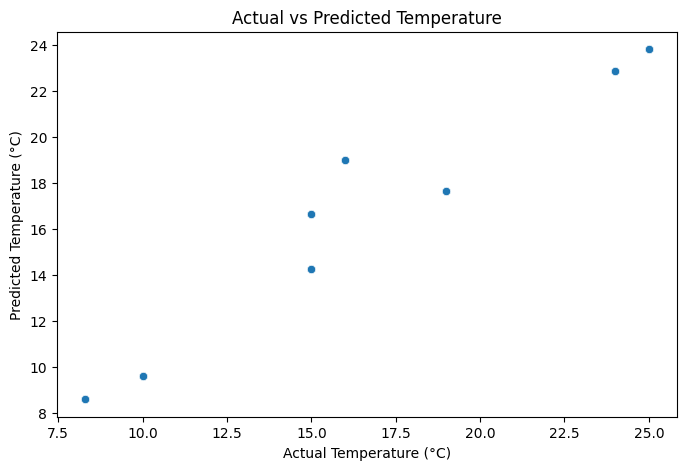

In [54]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperature')
plt.show()

#Types of Linear Regression & Accuracy Comparison
In this section, we will compare different types of linear regression models:

#Lasso Regression: L1 regularization (Lasso)
 encourages sparsity in the model by forcing some coefficients to be exactly zero, effectively selecting only a subset of features.
#Ridge Regression: L2 regularization (Ridge)
discourages large coefficients by shrinking them toward zero but usually does not force them to be exactly zero.

#We will evaluate these models based on their Mean Squared Error (MSE) and R-squared Score(R²).